<a href="https://colab.research.google.com/github/fischaaulia/datamining/blob/main/Data_Churn_PDAB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Preprocessing**



In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

Load data

In [ ]:
data = pd.read_csv('data_ecommerce_customer_churn.csv')
data.head()

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,NaN,230.27,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3941 entries, 0 to 3940
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Tenure                    3747 non-null   float64
 1   WarehouseToHome           3772 non-null   float64
 2   NumberOfDeviceRegistered  3941 non-null   int64  
 3   PreferedOrderCat          3941 non-null   object 
 4   SatisfactionScore         3941 non-null   int64  
 5   MaritalStatus             3941 non-null   object 
 6   NumberOfAddress           3941 non-null   int64  
 7   Complain                  3941 non-null   int64  
 8   DaySinceLastOrder         3728 non-null   float64
 9   CashbackAmount            3941 non-null   float64
 10  Churn                     3941 non-null   int64  
dtypes: float64(4), int64(5), object(2)
memory usage: 338.8+ KB


Analisis kali ini bertujuan untuk memprediksi potensi *Customer Churn* (berhentinya pelanggan) pada platform e-commerce. Dengan mengidentifikasi pelanggan yang berisiko pergi, perusahaan dapat mengambil tindakan preventif yang tepat sasaran.

# **Data Cleaning**

Mengisi Missing Values

In [ ]:
data['Tenure'] = data['Tenure'].fillna(data['Tenure'].median())
data['WarehouseToHome'] = data['WarehouseToHome'].fillna(data['WarehouseToHome'].median())
data['DaySinceLastOrder'] = data['DaySinceLastOrder'].fillna(data['DaySinceLastOrder'].median())

Mengubah data teks (kategorikal) menjadi angka

In [ ]:
data = pd.get_dummies(data, columns=['MaritalStatus', 'PreferedOrderCat'], drop_first=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3941 entries, 0 to 3940
Data columns (total 16 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Tenure                               3941 non-null   float64
 1   WarehouseToHome                      3941 non-null   float64
 2   NumberOfDeviceRegistered             3941 non-null   int64  
 3   SatisfactionScore                    3941 non-null   int64  
 4   NumberOfAddress                      3941 non-null   int64  
 5   Complain                             3941 non-null   int64  
 6   DaySinceLastOrder                    3941 non-null   float64
 7   CashbackAmount                       3941 non-null   float64
 8   Churn                                3941 non-null   int64  
 9   MaritalStatus_Married                3941 non-null   bool   
 10  MaritalStatus_Single                 3941 non-null   bool   
 11  PreferedOrderCat_Grocery      

Menentukan Fitur (X) dan Target (y)

In [ ]:
X = data.drop('Churn', axis=1)
y = data['Churn']

Membagi data menjadi Training (80%) dan Testing (20%)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# **Modeling**

Membuat model Decision Tree dengan kedalaman maksimal 5 level

In [ ]:
model = DecisionTreeClassifier(max_depth=5, random_state=42)

Melatih model dengan data training

In [ ]:
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

Melakukan prediksi pada data testing

In [ ]:
y_pred = model.predict(X_test)

Melihat akurasi

In [ ]:
print(f"Akurasi Model: {accuracy_score(y_test, y_pred):.2f}")
print("\nLaporan Klasifikasi:\n", classification_report(y_test, y_pred))

Akurasi Model: 0.89

Laporan Klasifikasi:
               precision    recall  f1-score   support

           0       0.92      0.96      0.94       660
           1       0.73      0.56      0.63       129

    accuracy                           0.89       789
   macro avg       0.82      0.76      0.78       789
weighted avg       0.89      0.89      0.89       789



Model Decision Tree menghasilkan nilai akurasi sebesar 0.89, yang menunjukkan bahwa model memiliki performa yang sangat baik (kategori Good Classifier). Model ini mampu mengenali pola perilaku pelanggan. Namun, hasil menunjukkan adanya indikasi bias akibat ketidakseimbangan data, di mana mayoritas pelanggan berada pada kelas 0 (stay), tercermin dari nilai F1-Score kelas 1 (churn) hanya sebesar 0.63. Nilai ini mengindikasikan bahwa model cenderung bias ke kelas 0 dan kurang optimal dalam mengenali pola pelanggan yang benar-benar akan berhenti. Secara bisnis, meskipun model cukup andal, perusahaan masih memiliki risiko gagal mendeteksi sekitar 37% potensi churn, sehingga diperlukan penguatan pada penanganan data imbalance untuk meningkatkan akurasi prediksi pada kelompok pelanggan yang kritis tersebut.


# **Visualisasi**

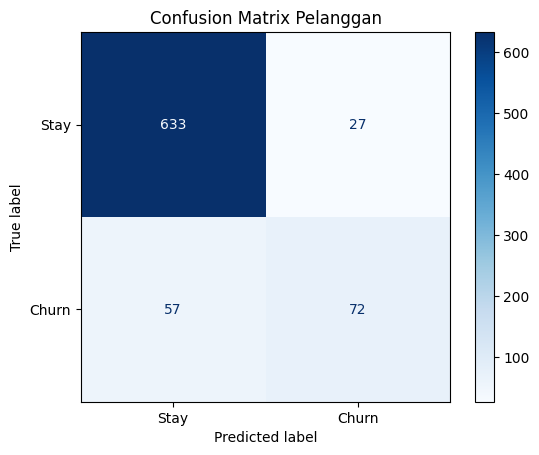

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Misal y_test adalah data asli dan y_pred adalah hasil prediksi modelmu
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stay', 'Churn'])

disp.plot(cmap='Blues')
plt.title('Confusion Matrix Pelanggan')
plt.show()

Model menunjukkan performa yang sangat kuat dalam memprediksi pelanggan yang akan bertahan (Stay) dengan keberhasilan sebanyak 633 data. Model juga berhasil mengidentifikasi 72 pelanggan yang akan berhenti (Churn) secara akurat. Meskipun terdapat 57 pelanggan yang gagal terdeteksi (missed) dan 27 pelanggan yang salah sasaran (false alarm), secara keseluruhan model memiliki tingkat akurasi yang tinggi.

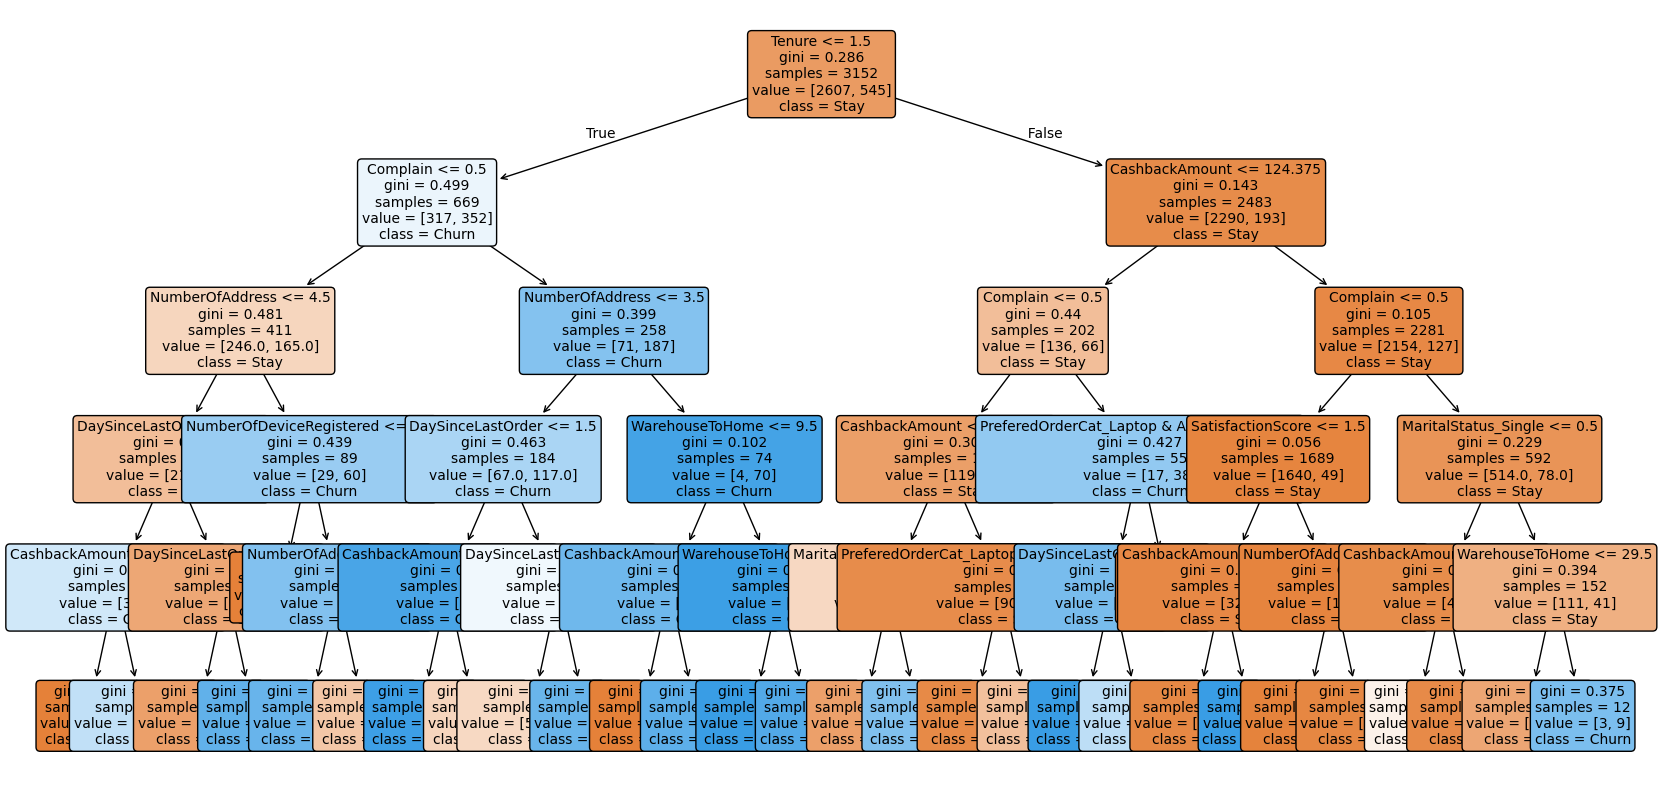

In [ ]:
plt.figure(figsize=(20,10))
plot_tree(model,
          feature_names=X.columns,
          class_names=['Stay', 'Churn'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.show()

Secara visual, pohon keputusan menunjukkan hierarki yang dimulai dari variabel Tenure dan Complain sebagai akar utama. Hal ini membuktikan bahwa masa berlangganan (Tenure) dan riwayat komplain (Complain) adalah filter terpenting dalam menentukan status pelanggan. Secara spesifik, visualisasi menunjukkan bahwa masa langganan yang lama (area orange) cenderung membuat pelanggan bertahan (Stay), sedangkan kombinasi masa langganan singkat dan adanya komplain akan mengarahkan pelanggan ke kelompok Churn (area biru).

# **Feature Importance**

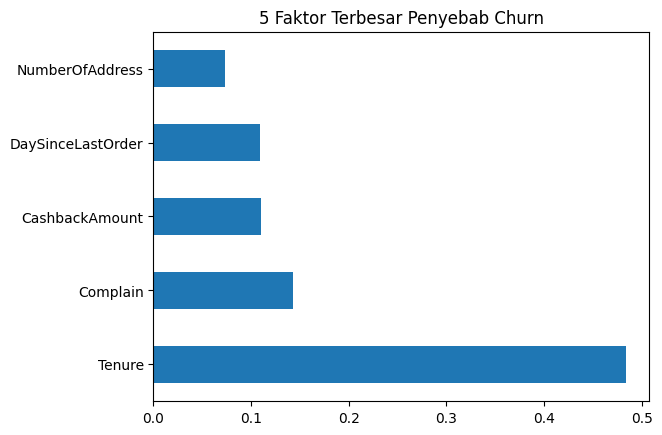

In [ ]:
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances.nlargest(5).plot(kind='barh')
plt.title('5 Faktor Terbesar Penyebab Churn')
plt.show()

Grafik ini menunjukkan variabel yang paling berkontribusi dalam keputusan model, di mana Tenure (masa langganan) muncul sebagai faktor dominan utama, disusul oleh Complain (komplain) dan CashbackAmount. Hal ini mengindikasikan bahwa loyalitas pelanggan sangat dipengaruhi oleh seberapa lama mereka telah menggunakan layanan dan pengalaman mereka terkait penanganan masalah. Secara bisnis, variabel dengan nilai tinggi pada grafik ini merupakan prioritas utama yang harus dikelola perusahaan; menjaga kepuasan pelanggan lama dan menangani komplain dengan cepat adalah strategi paling efektif untuk menekan angka churn berdasarkan pola data yang ditemukan.